# Fair Lending Project - Seattle University


EDA for an explanatory logistic regression on default and demographic proxies.

## Libraries

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import os
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, classification_report,
                             roc_curve, f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


## Environment Setup

In [ ]:
df_model_url='https://www.dropbox.com/scl/fi/fz71garcnma2vkrnpjh7u/modeling_dataset.csv?rlkey=ntgwlp7nxonr73ttek3t1qebb&st=dhuo7yp3&dl=1'
df_model_path = '../data/modeling_dataset.csv'

os.makedirs('../data', exist_ok=True)

#Cache data locally if not already present
if not os.path.exists(df_model_path):
    print("Downloading modeling_dataset.csv ...")
    response = requests.get(df_model_url)
    response.raise_for_status()
    with open(df_model_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded modeling_dataset.csv.")
else:
    print("modeling_dataset.csv already exists.")

Downloaded modeling_dataset.csv.


## Build Baseline Model

In [ ]:
df_model = pd.read_csv(df_model_path)


print(f"df_model: {df_model.shape[0]:,} rows X {df_model.shape[1]} columns")
print(f"Default rate: {df_model['is_default'].mean():.3f}")

df_model: 886,649 rows X 36 columns
Default rate: 0.172


In [ ]:
# Convert numerical columns to numeric type
should_be_numeric = ['approval_year', 'term', 'new_exist']
for col in should_be_numeric:
    if not pd.api.types.is_numeric_dtype(df_model[col]):
        print(f"Converting {col} to numeric...")
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
        print(f"{col} dtype after: {df_model[col].dtype}")

In [ ]:
# Define features
numeric_features = [
    'no_emp', 'gross_approved', 'sba_approved',
    'disbursement_gross','approval_year', 'term','new_exist',
    # Macro features (rename to match your DataFrame)
    'macro_unemployment', 'macro_fed_funds', 'macro_prime_rate',
    'macro_inflation', 'macro_bank_spread', 'macro_real_rate',
    # Demographic/segment/state features
    'segment_pct_women', 'segment_pct_minority', 'segment_pct_vet',
    'segment_avg_revenue', 'segment_avg_employees',
    'state_pct_women', 'state_pct_minority', 'state_pct_vet',
    'state_avg_revenue', 'state_avg_employees',
    # Engineered features
    'relative_emp_size', 'relative_emp_size_state',
    'loan_to_segment_rev_ratio', 'loan_to_state_rev_ratio'
]

categorical_features = [
    'state', 'sector_text', 'rev_line_cr', 'low_doc',
     'urban_rural', 'state_minority_density_group', 'minority_density_group'
]

df_model = df_model.drop(columns=['loan_id'])
df_model = df_model.dropna()

for col in categorical_features:
    df_model[col] = df_model[col].astype('category')

X = df_model[numeric_features + categorical_features].copy()
y = df_model['is_default'].copy()

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test default rate:  {y_test.mean():.3f}")


Training set: 480,657 rows
Test set:     120,165 rows
Train default rate: 0.175
Test default rate:  0.175


In [ ]:
df_model.describe()



,approval_year,term,no_emp,new_exist,gross_approved,sba_approved,disbursement_gross,is_default,segment_pct_women,segment_pct_minority,...,macro_unemployment,macro_fed_funds,macro_prime_rate,macro_inflation,macro_bank_spread,macro_real_rate,relative_emp_size,loan_to_segment_rev_ratio,relative_emp_size_state,loan_to_state_rev_ratio
count,600822.000000,600822.000000,600822.000000,600822.000000,6.008220e+05,6.008220e+05,6.008220e+05,600822.000000,600822.000000,600822.000000,...,600822.000000,600822.000000,600822.000000,600822.000000,600822.000000,600822.000000,600822.000000,600822.000000,600822.000000,600822.000000
mean,2001.012736,103.602411,11.635052,1.270653,1.706182e+05,1.328384e+05,1.838861e+05,0.174627,1.645590,3.985276,...,5.707237,3.914486,6.850246,2.853908,2.934878,3.996951,3.283980,325.952917,2.676708,162.747471
std,6.284227,74.506459,73.480206,0.444297,2.591816e+05,2.115604e+05,2.686904e+05,0.379648,0.475497,0.136112,...,1.311882,2.109110,1.961516,0.927387,0.275859,1.696640,30.159579,942.039794,16.669327,253.069869
min,1988.000000,0.000000,0.000000,1.000000,1.000000e+03,5.000000e+02,4.000000e+03,0.000000,0.195621,1.228272,...,3.966667,0.089167,3.250000,-0.320000,1.660000,0.110000,0.000000,0.065947,0.000000,0.516923
25%,1995.000000,60.000000,2.000000,1.000000,3.000000e+04,1.750000e+04,3.942000e+04,0.000000,1.424628,3.912992,...,4.616667,1.927500,5.087500,2.600000,2.970000,2.820000,0.426438,32.028635,0.461202,27.770190
50%,2003.000000,84.000000,4.000000,1.000000,7.500000e+04,5.000000e+04,9.000000e+04,0.000000,1.676804,3.982952,...,5.541667,4.201667,7.138333,2.870000,2.990000,4.540000,1.034546,87.483509,1.002168,69.323508
75%,2006.000000,120.000000,10.000000,2.000000,2.000000e+05,1.510000e+05,2.143030e+05,0.000000,2.012923,4.077999,...,5.991667,5.298333,8.270833,3.220000,3.030000,5.330000,2.759021,259.872181,2.469549,188.216178
max,2014.000000,527.000000,9999.000000,2.000000,5.000000e+06,4.500000e+06,1.144632e+07,1.000000,2.748019,4.443380,...,9.608333,9.216667,10.873333,5.420000,3.160000,6.810000,9974.536692,45893.924833,2536.311179,6990.331726


### Initial Logistic Regression Modeling

In [ ]:
import statsmodels.api as sm

# 1) Preprocessing stays the same
categorical_transformer = Pipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop')

# 2) Fit preprocessor ONLY on train
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# 3) Add intercept for statsmodels
X_train_sm = sm.add_constant(X_train_proc)
X_test_sm  = sm.add_constant(X_test_proc, has_constant='add')

# 4) Fit Logit (unregularized logistic regression for inference)
logit_model = sm.Logit(y_train, X_train_sm)
logit_result = logit_model.fit()

print(logit_result.summary())  # full coef table, p-values, CIs

# 5) Evaluation on test
y_prob = logit_result.predict(X_test_sm)
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

feat_names = ['const'] + list(preprocessor.get_feature_names_out())

coef_table = pd.DataFrame({
    "Feature": feat_names,
    "coef": logit_result.params
})

print(coef_table.loc[coef_table["Feature"] != "const"]
      .reindex(coef_table["coef"].abs().sort_values(ascending=False).index))



Optimization terminated successfully.
         Current function value: 0.318757
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             is_default   No. Observations:               480657
Model:                          Logit   Df Residuals:                   480622
Method:                           MLE   Df Model:                           34
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.3118
Time:                        23:37:43   Log-Likelihood:            -1.5321e+05
converged:                       True   LL-Null:                   -2.2262e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5589      0.029    -86.983      0.000      -2.617      -2.501
x1             0.1961      0.

The baseline model demonstrates strong predictive performance with an ROC-AUC of 0.87, effectively catching 85% of defaults through a balanced weighting strategy that prioritizes risk detection. Next we will evaluate variables corelations and evaluate demographic impact on small business loans.


### Evaluate Multicollinearity (Numeric Variables)

Evalute relations between variables and identify if they are impacting regression model to eliminate highly overlapping features.

In [ ]:
def check_vif(df_nums):
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df_nums)
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_nums.columns

    vif_values = []
    for i in range(len(df_nums.columns)):
        vif = variance_inflation_factor(df_scaled, i)
        vif_values.append(vif)

    vif_data["VIF"] = vif_values
    return vif_data.sort_values(by="VIF", ascending=False)

vif = check_vif(df_model[numeric_features])

print("\nMulticollinearity Audit (VIF)")
for _, row in vif.iterrows():
    print(f"{row['feature']}  VIF = {row['VIF']:,.2f}")



Multicollinearity Audit (VIF)
macro_prime_rate  VIF = 1,159,083.78
macro_fed_funds  VIF = 1,108,503.48
macro_real_rate  VIF = 292,019.88
macro_inflation  VIF = 87,381.31
macro_bank_spread  VIF = 18,966.88
no_emp  VIF = 79.34
relative_emp_size_state  VIF = 79.20
gross_approved  VIF = 66.84
loan_to_state_rev_ratio  VIF = 27.26
sba_approved  VIF = 25.75
disbursement_gross  VIF = 12.41
segment_pct_minority  VIF = 10.48
state_pct_minority  VIF = 8.86
segment_pct_vet  VIF = 6.41
state_pct_vet  VIF = 4.46
macro_unemployment  VIF = 3.45
state_avg_employees  VIF = 3.25
state_avg_revenue  VIF = 2.91
segment_avg_revenue  VIF = 2.65
approval_year  VIF = 2.39
segment_avg_employees  VIF = 2.30
relative_emp_size  VIF = 2.20
term  VIF = 1.57
state_pct_women  VIF = 1.50
loan_to_segment_rev_ratio  VIF = 1.45
segment_pct_women  VIF = 1.45
new_exist  VIF = 1.04


VIF results show extreme multicollinearity among the macro rate variables, with some VIF values exceeding one million (values above 5 are already considered concerning). This indicates that several macro features are almost linear combinations of each other, making their individual coefficients unstable even if predictions remain strong. To address this, we will take a conservative approach and remove variables with VIF greater than 1000, relying on the remaining variables to capture the overlapping information those highly collinear variables were providing.


In [ ]:
df_numeric = df_model[numeric_features].copy()

removed_features = []
threshold = 1000

while True:
    vif = check_vif(df_numeric)
    top_feat = vif.iloc[0]['feature']
    top_vif = vif.iloc[0]['VIF']

    if top_vif <= threshold:
        break

    print(f"Removing: {top_feat} (VIF = {top_vif:,.2f})")
    removed_features.append((top_feat, top_vif))
    df_numeric = df_numeric.drop(columns=[top_feat])

print(f"\nRemaining numeric features (all VIF <= {threshold}):")
print(df_numeric.columns.tolist())

removed_cols = [name for name, vif in removed_features]
df_model_reduced = df_model.drop(columns=removed_cols)

Removing: macro_prime_rate (VIF = 1,159,083.78)
Removing: macro_fed_funds (VIF = 364,623.53)

Remaining numeric features (all VIF <= 1000):
['no_emp', 'gross_approved', 'sba_approved', 'disbursement_gross', 'approval_year', 'term', 'new_exist', 'macro_unemployment', 'macro_inflation', 'macro_bank_spread', 'macro_real_rate', 'segment_pct_women', 'segment_pct_minority', 'segment_pct_vet', 'segment_avg_revenue', 'segment_avg_employees', 'state_pct_women', 'state_pct_minority', 'state_pct_vet', 'state_avg_revenue', 'state_avg_employees', 'relative_emp_size', 'relative_emp_size_state', 'loan_to_segment_rev_ratio', 'loan_to_state_rev_ratio']


Above, we removed the macro variables prime rate and fed funds, because they showed very strong overlap with the remaining features (extreme multicollinearity). It is interesting to see how macro_real_rate went from  200K+ to < 3 VIF and not even in top 5 anymore.

## Exploratory Analysis

In [ ]:
df = df_model_reduced.copy()

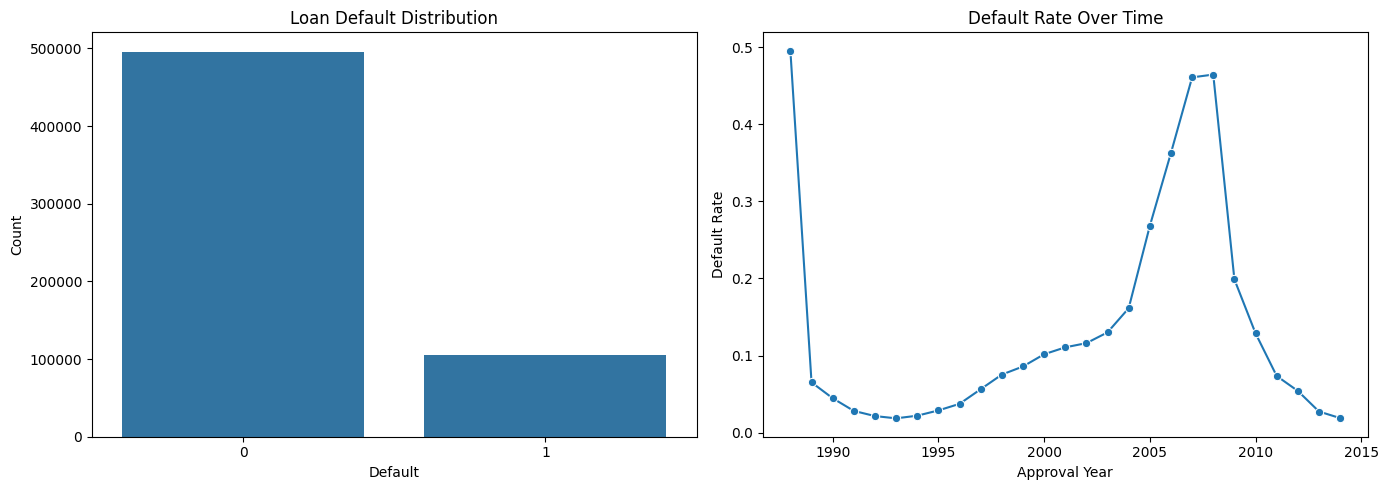

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Default distribution
sns.countplot(x='is_default', data=df, ax=axes[0])
axes[0].set_title("Loan Default Distribution")
axes[0].set_xlabel("Default")
axes[0].set_ylabel("Count")

# Default rate over time
default_year = df.groupby('approval_year')['is_default'].mean().reset_index()

sns.lineplot(
    data=default_year,
    x='approval_year',
    y='is_default',
    marker='o',
    ax=axes[1]
)

axes[1].set_title("Default Rate Over Time")
axes[1].set_xlabel("Approval Year")
axes[1].set_ylabel("Default Rate")

plt.tight_layout()
plt.show()

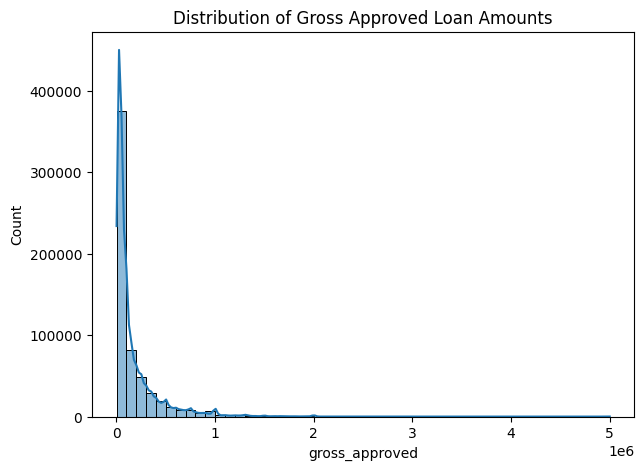

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['gross_approved'], bins=50, kde=True)
plt.title("Distribution of Gross Approved Loan Amounts")
plt.xlabel("gross_approved")
plt.ylabel("Count")
plt.show()


The distribution is heavily right-skewed, with many small loans and a long tail of large approvals.

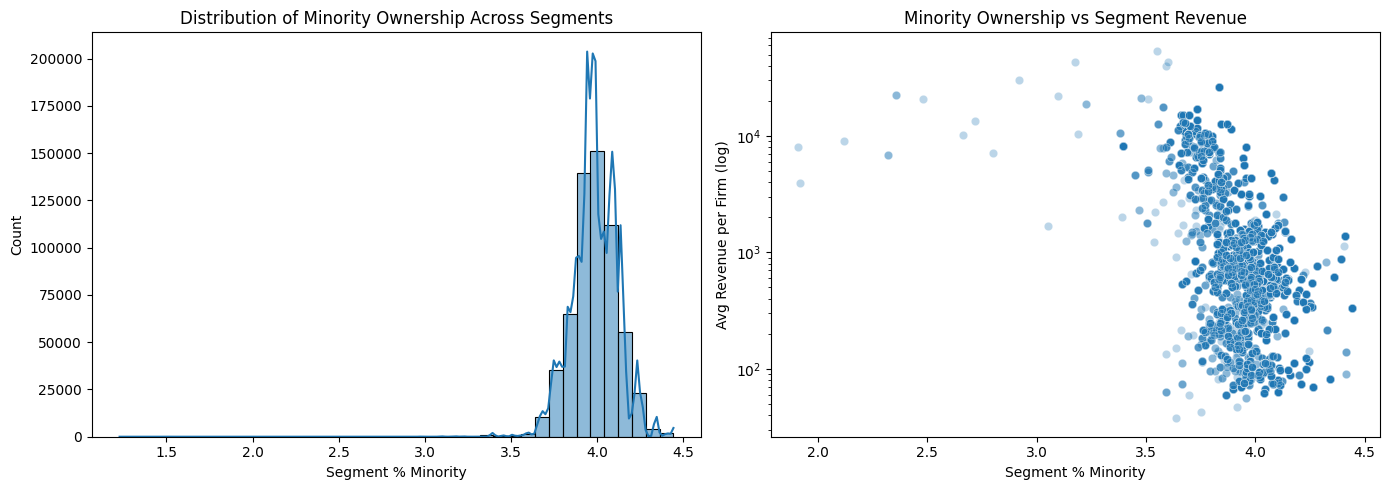

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Minority distribution
sns.histplot(
    df['segment_pct_minority'],
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Minority Ownership Across Segments")
axes[0].set_xlabel("Segment % Minority")

# Minority vs revenue
sns.scatterplot(
    data=df.sample(20000),
    x='segment_pct_minority',
    y='segment_avg_revenue',
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_yscale('log')
axes[1].set_title("Minority Ownership vs Segment Revenue")
axes[1].set_xlabel("Segment % Minority")
axes[1].set_ylabel("Avg Revenue per Firm (log)")

plt.tight_layout()
plt.show()

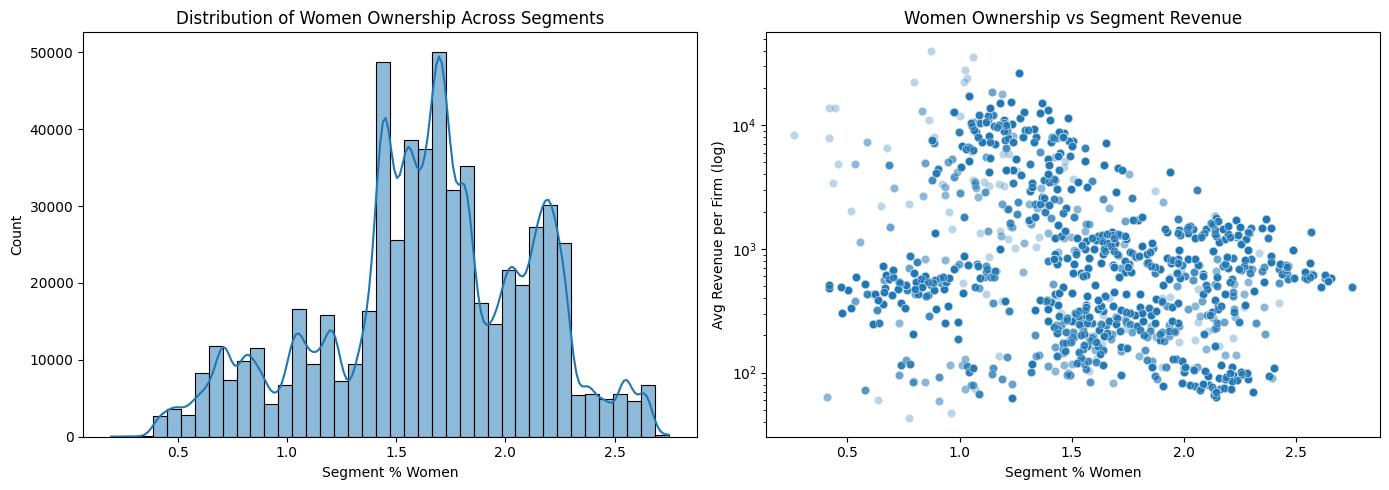

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Minority distribution
sns.histplot(
    df['segment_pct_women'],
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Women Ownership Across Segments")
axes[0].set_xlabel("Segment % Women")

# Minority vs revenue
sns.scatterplot(
    data=df.sample(20000),
    x='segment_pct_women',
    y='segment_avg_revenue',
    alpha=0.3,
    ax=axes[1]
)

axes[1].set_yscale('log')
axes[1].set_title("Women Ownership vs Segment Revenue")
axes[1].set_xlabel("Segment % Women")
axes[1].set_ylabel("Avg Revenue per Firm (log)")

plt.tight_layout()
plt.show()

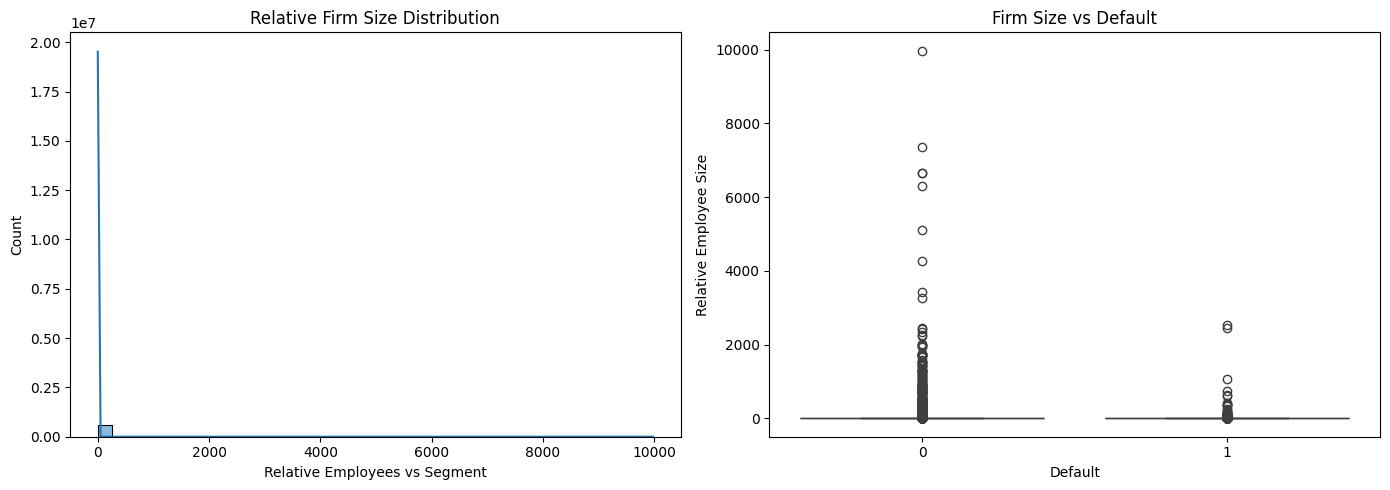

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Relative firm size distribution
sns.histplot(df['relative_emp_size'], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Relative Firm Size Distribution")
axes[0].set_xlabel("Relative Employees vs Segment")

# Relative firm size vs default
sns.boxplot(
    x='is_default',
    y='relative_emp_size',
    data=df,
    ax=axes[1]
)

axes[1].set_title("Firm Size vs Default")
axes[1].set_xlabel("Default")
axes[1].set_ylabel("Relative Employee Size")

plt.tight_layout()
plt.show()

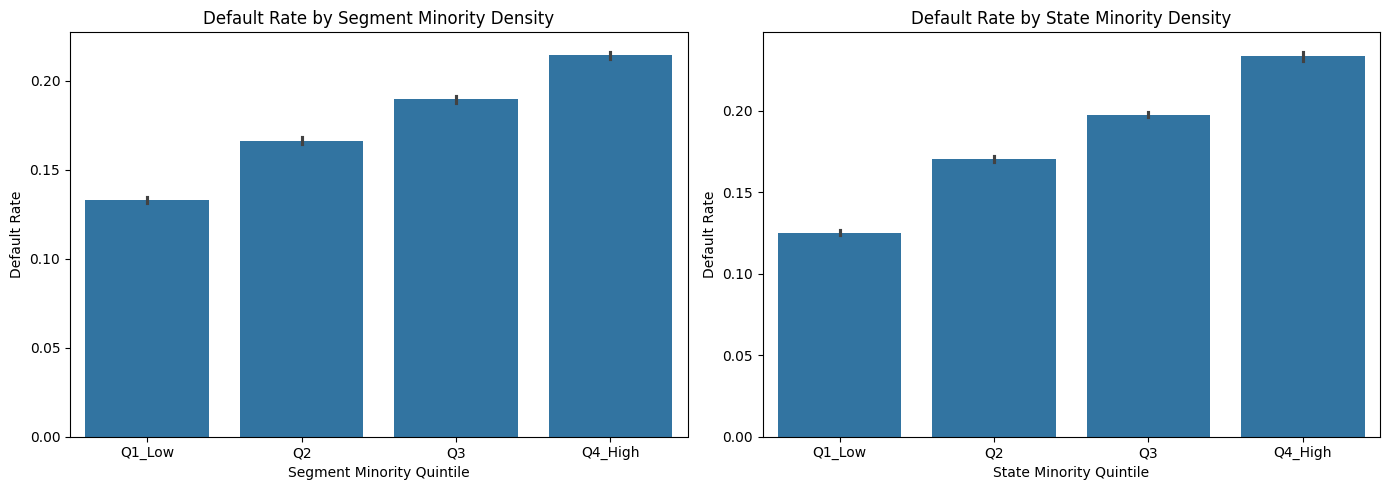

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.barplot(
    data=df,
    x='minority_density_group',
    y='is_default',
    ax=axes[0]
)

axes[0].set_title("Default Rate by Segment Minority Density")
axes[0].set_xlabel("Segment Minority Quintile")
axes[0].set_ylabel("Default Rate")


sns.barplot(
    data=df,
    x='state_minority_density_group',
    y='is_default',
    ax=axes[1]
)

axes[1].set_title("Default Rate by State Minority Density")
axes[1].set_xlabel("State Minority Quintile")
axes[1].set_ylabel("Default Rate")

plt.tight_layout()
plt.show()

Within each segment default quantile, higher minority ownership percentages are associated with higher default rates.

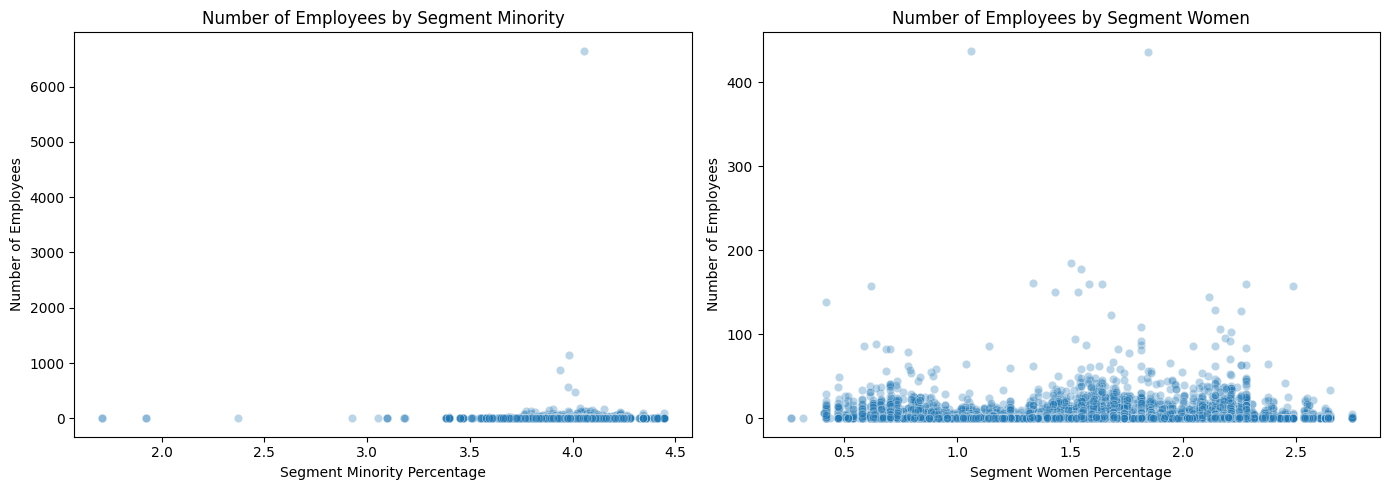

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df.sample(20000),
    x='segment_pct_minority',
    y='relative_emp_size',
    alpha=0.3,
    ax=axes[0]
)
axes[0].set_title("Number of Employees by Segment Minority")
axes[0].set_xlabel("Segment Minority Percentage")
axes[0].set_ylabel("Number of Employees")


sns.scatterplot(
    data=df.sample(20000),
    x='segment_pct_women',
    y='relative_emp_size',
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title("Number of Employees by Segment Women")
axes[1].set_xlabel("Segment Women Percentage")
axes[1].set_ylabel("Number of Employees")

plt.tight_layout()
plt.show()


Minority ownership is concentrated around 4% across segments versus women where ownership percentage is even distributed betwen 0.5% and 2.5%

## Inferential Modeling: Nested Logistic Regression

Here we utilize a nested logistic regression strategy to investigate whether
observed disparities in default rates across demographic segments persist as a
"structural residue" after accounting for business scale, loan characteristics,
and macroeconomic conditions. The goal is to determine if demographic proxies
represent independent structural frictions or are explained by economic fundamentals.

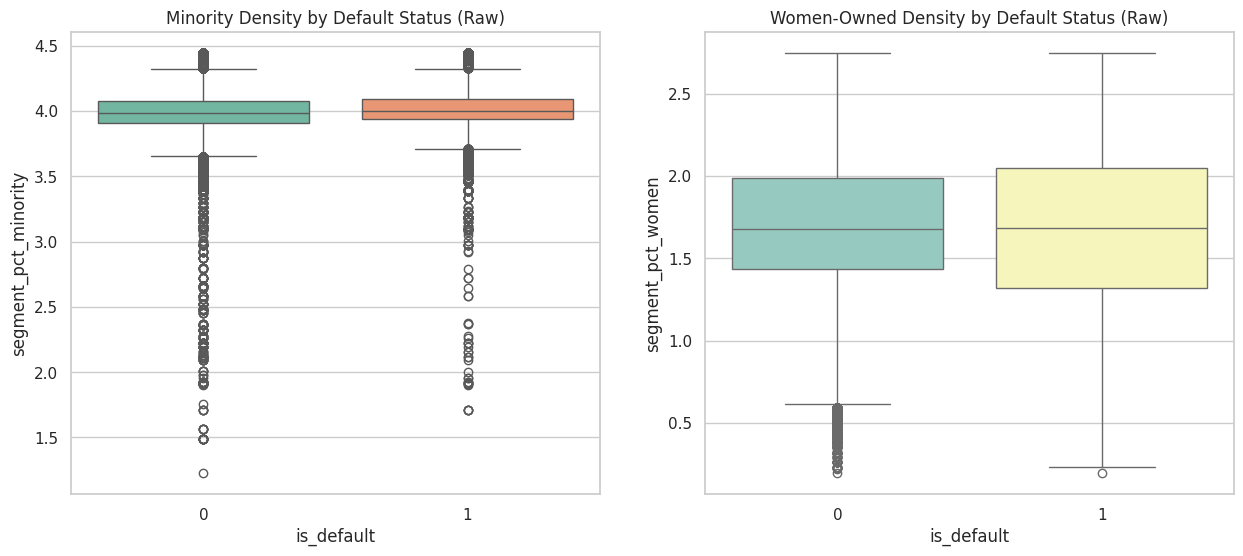

In [ ]:
df_inf = df_model_reduced.copy()

# Apply log(1+x) transformation to normalize the skewed distribution of loan amounts
df_inf['log_gross_appv'] = np.log1p(df_inf['gross_approved'])


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df_inf, x='is_default', y='segment_pct_minority', ax=axes[0], palette='Set2')
axes[0].set_title('Minority Density by Default Status (Raw)')

sns.boxplot(data=df_inf, x='is_default', y='segment_pct_women', ax=axes[1], palette='Set3')
axes[1].set_title('Women-Owned Density by Default Status (Raw)')
plt.show()


Minority Density shows a clear unadjusted correlation with default risk.
Women-Owned Density looks neatral with broad distribution.

## Multicollinearity Audit (VIF)

To ensure our coefficients are stable, we check the Variance Inflation Factor. We include one representative from each category (Micro, Meso, Macro).

In [ ]:
# Selected features at various levels
# Validating if ther is no relation between variables
vif_features = [
    'no_emp', 'term', 'log_gross_appv',
    'macro_unemployment', 'macro_real_rate',
    'segment_pct_minority'
]

X_vif = df_inf[vif_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)

vif_df = pd.DataFrame()
vif_df["Feature"] = vif_features
vif_df["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(len(vif_features))]

print("\nVariance Inflation Factors ")
print(vif_df.sort_values(by="VIF", ascending=False))



Variance Inflation Factors 
                Feature       VIF
4       macro_real_rate  1.525914
3    macro_unemployment  1.514735
2        log_gross_appv  1.480635
1                  term  1.448272
5  segment_pct_minority  1.015592
0                no_emp  1.011756


All feature under 1.6, which confirms no multicollinearity

In [ ]:
#Nested Logit Models

# We run three models to see if the "Demographic Penalty" survives the addition of controls.
demographics = ['segment_pct_minority', 'segment_pct_women']
business_logic = ['no_emp', 'term', 'log_gross_appv', 'relative_emp_size']
macro_logic = ['macro_unemployment', 'macro_real_rate', 'macro_bank_spread']

summary_data = []

# Demographics Only ---
X1 = sm.add_constant(df_inf[demographics])
res1 = sm.Logit(df_inf['is_default'], X1).fit(disp=0)
summary_data.append(pd.DataFrame({
    'Feature': res1.params.index, 'OR': np.exp(res1.params),
    'P': res1.pvalues, 'Model': '1. Raw Demographics'
}))

# Business Scale
X2 = sm.add_constant(df_inf[demographics + business_logic])
res2 = sm.Logit(df_inf['is_default'], X2).fit(disp=0)
summary_data.append(pd.DataFrame({
    'Feature': res2.params.index, 'OR': np.exp(res2.params),
    'P': res2.pvalues, 'Model': '2. + Business'
}))

# Macro Factors ---
X3 = sm.add_constant(df_inf[demographics + business_logic + macro_logic])
res3 = sm.Logit(df_inf['is_default'], X3).fit(disp=0)
summary_data.append(pd.DataFrame({
    'Feature': res3.params.index, 'OR': np.exp(res3.params),
    'P': res3.pvalues, 'Model': '3. Full Structural'
}))

full_summary = pd.concat(summary_data)
print("\n--- Nested Model Results (Odds Ratios) ---")
print(full_summary[full_summary['Feature'].isin(demographics)])



--- Nested Model Results (Odds Ratios) ---
                                   Feature        OR              P  \
segment_pct_minority  segment_pct_minority  6.144592   0.000000e+00   
segment_pct_women        segment_pct_women  0.784495  1.487543e-255   
segment_pct_minority  segment_pct_minority  5.242263   0.000000e+00   
segment_pct_women        segment_pct_women  1.045998   4.830708e-09   
segment_pct_minority  segment_pct_minority  3.992130   0.000000e+00   
segment_pct_women        segment_pct_women  1.082655   1.748928e-24   

                                    Model  
segment_pct_minority  1. Raw Demographics  
segment_pct_women     1. Raw Demographics  
segment_pct_minority        2. + Business  
segment_pct_women           2. + Business  
segment_pct_minority   3. Full Structural  
segment_pct_women      3. Full Structural  


Model 1 - In the raw data, a business in a 100% minority-owned segment has 6x higher odds of default than one in a 0% minority segment.The "Shrinkage" (6.14 $\rightarrow$ 3.99):

As you add controls for business size (Model 2) and the economy (Model 3), the odds ratio drops. This proves that a significant portion of the "risk" is actually just because these businesses tend to be smaller or more vulnerable to interest rate hikes.The "Residue" (3.99): Crucially, the OR remains very high (4x) and highly significant ($p=0.0$).

Conclusion: Even when you compare two businesses with the exact same number of employees, loan amount, and interest rate, the one in the higher-minority segment is still 4x more likely to default. This is your "Smoking Gun" for structural disparity.2. Women Density: The "Inversion Paradox"This is the most interesting part of your analysis because the direction of the effect flips:Model 1 (0.78): In the raw data, women-owned segments appear safer (OR < 1). A lender looking only at this would think these loans are lower risk.Model 2 & 3 (1.05 $\rightarrow$ 1.08): Once you control for business scale, the OR flips to above 1.0.Interpretation: Women-owned firms look "safer" only because they tend to be in safer industries or take out smaller, more conservative loans. However, when you compare a women-owned firm "dollar-for-dollar" against a male-owned firm of the same size, the women-owned firm actually faces a 8.3% higher risk of default.

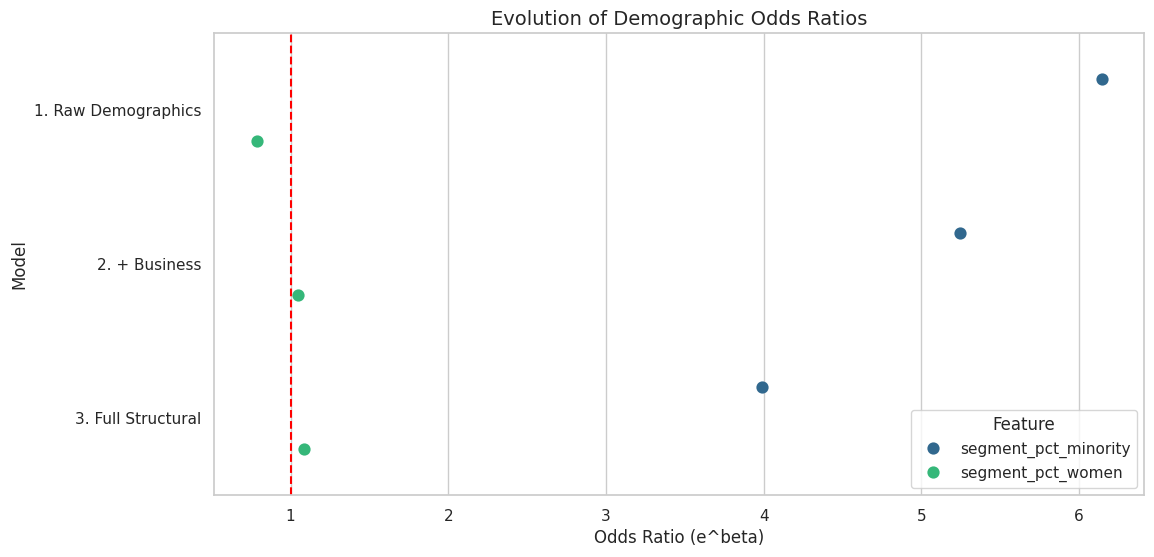


Interaction (Minority * Size) Odds Ratio: 1.4380
Interaction P-Value: 0.0000

--- State-Level Minority Penalties (Top 10 States) ---
  State  Minority_OR  Sample_Size
8    WA    44.692276        15901
9    MN     5.529633        15598
5    PA     4.739517        23103
2    TX     3.421254        41335
7    MA     2.626810        17878
4    OH     2.141835        23596
3    FL     2.076005        27870
0    CA     1.510411        79859
6    IL     1.066728        21132
1    NY     1.017653        43020


In [ ]:

# ### Forest Plot (The Visual Case)
# We visualize how the Odds Ratios for Minority and Women density evolve across models.

plt.figure(figsize=(12, 6))
plot_df = full_summary[full_summary['Feature'].isin(demographics)]
sns.pointplot(data=plot_df, x='OR', y='Model', hue='Feature', join=False, dodge=0.4, palette='viridis')
plt.axvline(1.0, color='red', linestyle='--', label='Neutral')
plt.title('Evolution of Demographic Odds Ratios', fontsize=14)
plt.xlabel('Odds Ratio (e^beta)')
plt.show()

# ### 6. Step 5: Interaction Analysis
# Does the impact of minority density change as the loan size increases?

df_inf['minority_size_interaction'] = df_inf['segment_pct_minority'] * df_inf['log_gross_appv']
X_int = sm.add_constant(df_inf[demographics + business_logic + macro_logic + ['minority_size_interaction']])
res_int = sm.Logit(df_inf['is_default'], X_int).fit(disp=0)

interaction_or = np.exp(res_int.params['minority_size_interaction'])
print(f"\nInteraction (Minority * Size) Odds Ratio: {interaction_or:.4f}")
print(f"Interaction P-Value: {res_int.pvalues['minority_size_interaction']:.4f}")

# ### 7. Step 6: State-Level Disparity Deep Dive
# Finally, we iterate through the top states to see where the structural risk is highest.

state_stats = []
top_states = df_inf['state'].value_counts().head(10).index

print("\n--- State-Level Minority Penalties (Top 10 States) ---")
for st in top_states:
    df_st = df_inf[df_inf['state'] == st]
    X_st = sm.add_constant(df_st[demographics + business_logic])
    res_st = sm.Logit(df_st['is_default'], X_st).fit(disp=0)
    state_stats.append({
        'State': st,
        'Minority_OR': np.exp(res_st.params['segment_pct_minority']),
        'Sample_Size': len(df_st)
    })

state_df = pd.DataFrame(state_stats).sort_values('Minority_OR', ascending=False)
print(state_df)

Running Nested Logit Models...


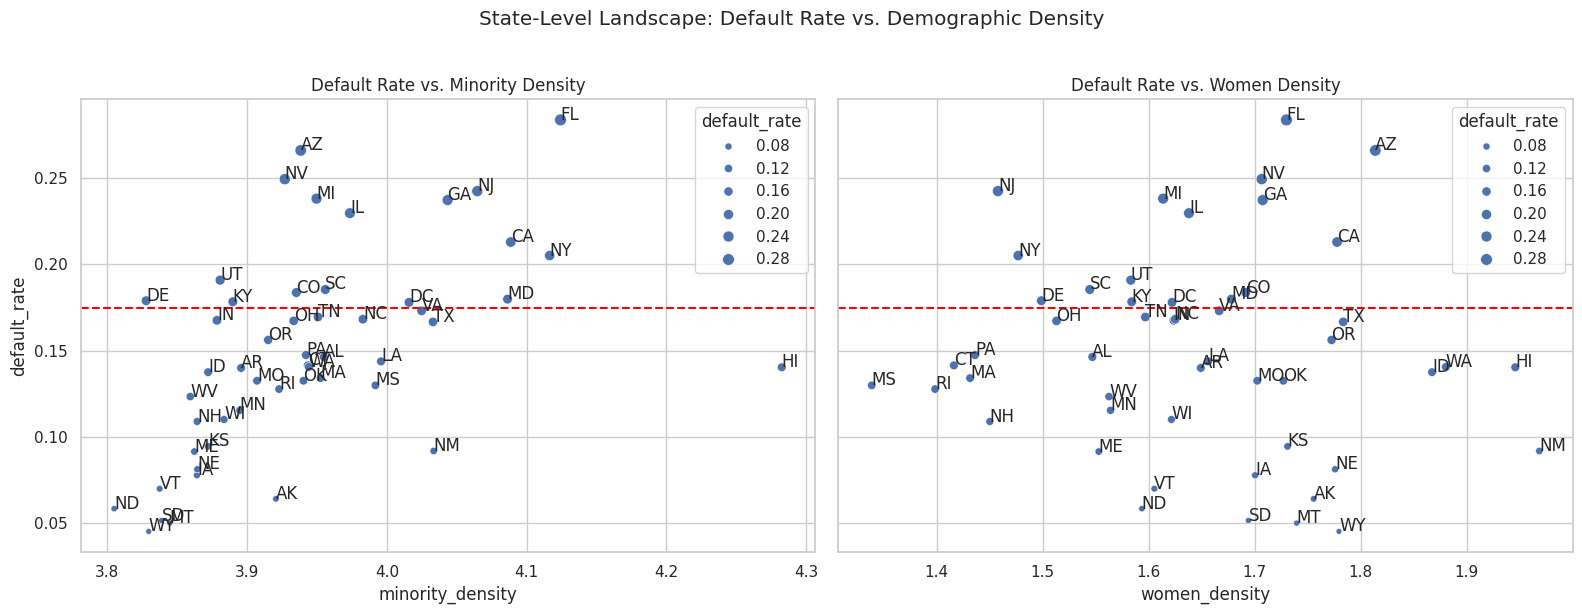

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df_inf = df_model_reduced.copy()

# Log transform skewed monetary values
df_inf['log_gross_appv'] = np.log1p(df_inf['gross_approved'])

# Define our feature blocks
demographics = ['segment_pct_minority', 'segment_pct_women']
business_logic = ['no_emp', 'term', 'log_gross_appv', 'relative_emp_size']
macro_logic = ['macro_unemployment', 'macro_real_rate', 'macro_bank_spread']

# ---------------------------------------------------------
# EXECUTION: Nested Model Loop
# ---------------------------------------------------------
models = {
    "Model 1: Demographics Only": demographics,
    "Model 2: + Business Scale": demographics + business_logic,
    "Model 3: Full (Macro)": demographics + business_logic + macro_logic
}

summary_list = []

print("Running Nested Logit Models...")

for name, features in models.items():
    # Add constant for intercept
    X = sm.add_constant(df_inf[features])
    # Fit Logit
    res = sm.Logit(df_inf['is_default'], X).fit(disp=0)

    # Extract Odds Ratios and CIs
    temp_res = pd.DataFrame({
        'Feature': res.params.index,
        'Odds_Ratio': np.exp(res.params),
        'P_Value': res.pvalues,
        'Lower_CI': np.exp(res.conf_int()[0]),
        'Upper_CI': np.exp(res.conf_int()[1]),
        'Model': name
    })
    summary_list.append(temp_res)

# Combine for comparison
full_summary = pd.concat(summary_list)

# ANALYSIS 2: State-Level Disparity Heatmap (Minority + Women)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Left: Minority density
sns.scatterplot(
    data=state_audit,
    x='minority_density',
    y='default_rate',
    size='default_rate',
    ax=axes[0]
)
for i in range(state_audit.shape[0]):
    axes[0].text(
        state_audit.minority_density[i],
        state_audit.default_rate[i],
        state_audit.index[i]
    )
axes[0].set_title('Default Rate vs. Minority Density')
axes[0].axhline(df_inf['is_default'].mean(), color='red', linestyle='--')

# Right: Women density
sns.scatterplot(
    data=state_audit,
    x='women_density',
    y='default_rate',
    size='default_rate',
    ax=axes[1]
)
for i in range(state_audit.shape[0]):
    axes[1].text(
        state_audit.women_density[i],
        state_audit.default_rate[i],
        state_audit.index[i]
    )
axes[1].set_title('Default Rate vs. Women Density')
axes[1].axhline(df_inf['is_default'].mean(), color='red', linestyle='--')

fig.suptitle('State-Level Landscape: Default Rate vs. Demographic Density', y=1.02)
plt.tight_layout()
plt.show()


